In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

from grb.utils import unit_conversion
from grb.sed import *

## 7DT SED fit

In [7]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)
x0 = pivot_finder(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], df_sdt["flux_error_mJy"])
print(x0/1e14)

Optimal Pivot: 5.90e+14
5.903434426266961


In [8]:
eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=x0) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_error_mJy"], x_data_error=df_sdt["frequency_error_Hz"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+01   [-52.1695..-52.1694]*| it/evals=4186/111290 eff=3.7715% N=300       0      
[ultranest] Likelihood function evaluations: 111483
[ultranest]   logZ = -61.51 +- 0.1577
[ultranest] Effective samples strategy satisfied (ESS = 1170.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.


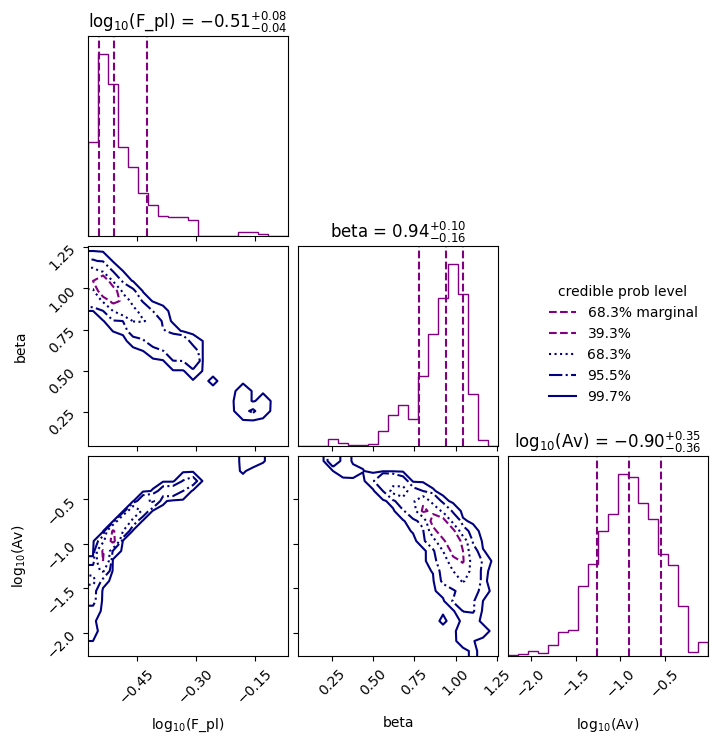

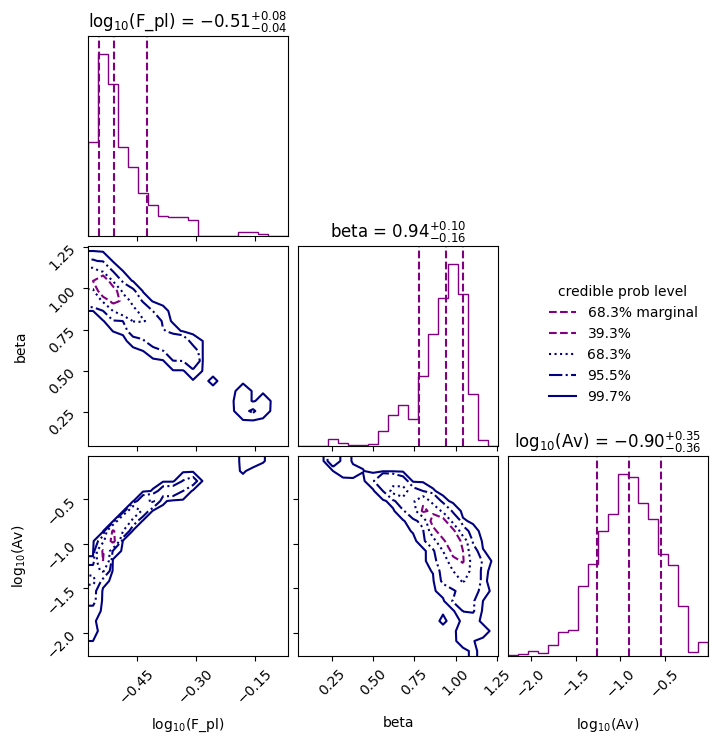

In [9]:
alz_sed.plot_corner()

In [ ]:
df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["Flux_high"], df_filtered["Flux_low"])])
alz_xrt = Analyzer(df_filtered["Time"]/3600, df_filtered["Flux"], power_law, y_data_error=y_err)
alz_xrt.run(method="curve_fit")

In [ ]:
ax = plt.gca()

nu_grid = np.geomspace(min(alz_sed.x_data), max(alz_sed.x_data), 100)

power_law_sed = lambda x, *params: power_law(x, *params[:2], x0=x0)
dataset = alz_sed.get_posterior_predictive_curve(nu_grid, model=power_law_sed, param_indices=[0, 1])

plot_sed(nu_grid, power_law(nu_grid, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", label="7DT (6.5 hrs)")
plot_sed_from_samples(dataset, ax=ax, y_unit="sed", x_unit="eV")

extrapolate_range = np.geomspace(unit_conversion(1, "eV", "Hz"), unit_conversion(200, "keV", "Hz"), 100)
plot_sed(extrapolate_range, power_law(extrapolate_range, *alz_sed.best_fit_params[:2], x0=x0), ax=ax, y_unit="sed", x_unit="eV", color="gray", ls="--", lw=0.5)

ax.set_xlim(1, 20000)
ax.set_ylim(9e-13, 2e-11)

ax.axvspan(unit_conversion(min(alz_sed.x_data), "Hz", "eV"), unit_conversion(max(alz_sed.x_data), "Hz", "eV"), color="C0", alpha=0.2)
ax.axvspan(300, 10000, color="C1", alpha=0.2)

ax.plot([300, 10000], [alz_xrt.model(6.5), alz_xrt.model(6.5)], color="C1", ls="--", label="XRT (interpolated at 6.5 hrs)")
ax.legend()
ax.grid()

In [ ]:
from grb.utils import unit_conversion

In [ ]:
10**((np.log10(10000)+np.log10(300))/2)

In [ ]:
data = alz_sed.get_posterior_predictive_curve([unit_conversion(2000, "eV", "Hz")], model=power_law_sed, param_indices=[0, 1])

In [ ]:
data_erg = mJy_to_erg_cm2_s(data[0][1:], unit_conversion(2000, "eV", "Hz"))

In [ ]:
alz_xrt.plot_data(label="XRT")
ax = alz_xrt.plot_model(color="red", lw=0.5, alpha=0.5)
ax.errorbar(6.5, data_erg[1], yerr=[[data_erg[1]-data_erg[0]], [data_erg[2]-data_erg[1]]])
ax.axvline(6.5, color="C1", ls=":", label="XRT (predicted at 6.5 hrs)")
